# Random Forest Classification Masterclass

Canonical, fully executed masterclass using the same structure as Linear and Logistic Regression: mathematics, exhaustive EDA, leakage-safe modeling, diagnostics, tuning, interpretation, untouched-test evaluation, inference contract, and model card.

## Learning map

Problem and costs → mathematics → audit → univariate EDA → bivariate/multivariate EDA → split isolation → baseline → model → capacity/stability → tuning → importance → threshold policy → untouched test → subgroup/error analysis → deployment contract.

In [1]:
from pathlib import Path
import json,platform,sys,warnings
warnings.filterwarnings("ignore")
import joblib,matplotlib.pyplot as plt,numpy as np,pandas as pd,sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance,PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,average_precision_score,balanced_accuracy_score,brier_score_loss,classification_report,ConfusionMatrixDisplay,confusion_matrix,f1_score,log_loss,matthews_corrcoef,PrecisionRecallDisplay,roc_auc_score,RocCurveDisplay
from sklearn.model_selection import GridSearchCV,LearningCurveDisplay,StratifiedKFold,cross_validate,train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
SEED=4317;np.random.seed(SEED);pd.set_option("display.max_columns",100);ROOT=Path.cwd();DATA=ROOT/"data"/"loan_default_teaching.csv";(ROOT/"artifacts").mkdir(exist_ok=True);print({"python":sys.version.split()[0],"numpy":np.__version__,"pandas":pd.__version__,"sklearn":sklearn.__version__})

{'python': '3.12.13', 'numpy': '2.3.5', 'pandas': '2.2.3', 'sklearn': '1.8.0'}


## Random-forest mathematics\n\nFor $B$ randomized trees, $\\hat p(x)=B^{-1}\\sum_b\\hat p_b(x)$. Bootstrap samples randomize rows; random feature subsets reduce tree correlation. Approximate variance is $\\rho\\sigma^2+(1-\\rho)\\sigma^2/B$.

## 1. Problem framing and data contract

Predict synthetic default probability. False negatives cost six times false positives. Exclude the identifier. The data are synthetic and cannot support real lending, causal, fairness, or policy claims.

In [2]:
df=pd.read_csv(DATA);assert df.customer_id.is_unique;display(df.head());display(pd.DataFrame({"dtype":df.dtypes.astype(str),"missing_n":df.isna().sum(),"missing_pct":100*df.isna().mean(),"unique":df.nunique(dropna=False)}));display(df.default.value_counts().rename("count").to_frame().assign(proportion=df.default.value_counts(normalize=True)))

,customer_id,age,annual_income,employment_years,credit_score,debt_ratio,missed_payments_12m,loan_amount,interest_rate,prior_default,home_ownership,purpose,region,channel,application_month,default
0,CUST-00001,51,39533.76,3.7,598,0.469,0,4558.30,8.07,0,RENT,debt_consolidation,north,branch,10,0
1,CUST-00002,55,125261.09,12.3,638,0.225,0,15241.73,5.31,0,RENT,debt_consolidation,east,web,12,0
2,CUST-00003,67,58169.67,9.0,710,0.066,1,8504.40,4.39,0,RENT,small_business,west,branch,11,0
3,CUST-00004,34,31365.51,5.2,648,0.548,0,8641.82,7.12,0,OTHER,small_business,south,web,6,0
4,CUST-00005,34,147184.75,5.4,742,0.405,2,7387.29,5.92,0,OWN,vehicle,west,partner,11,0


,dtype,missing_n,missing_pct,unique
customer_id,object,0,0.000000,2400
age,int64,0,0.000000,50
annual_income,float64,60,2.500000,2322
employment_years,float64,84,3.500000,214
credit_score,int64,0,0.000000,352
debt_ratio,float64,43,1.791667,674
missed_payments_12m,int64,0,0.000000,6
loan_amount,float64,0,0.000000,2383
interest_rate,float64,0,0.000000,691
prior_default,int64,0,0.000000,2


,count,proportion
default,,
0,2161,0.900417
1,239,0.099583


## 2. Univariate analysis

Inspect every feature for scale, skew, discreteness, missingness, outliers, cardinality, and rare levels.

,count,mean
prior_default,,
1,232,0.146552
0,2168,0.094557


,count,mean
home_ownership,,
OTHER,71,0.140845
MORTGAGE,972,0.105967
RENT,946,0.102537
NaN,28,0.071429
OWN,383,0.070496


,count,mean
purpose,,
vehicle,402,0.114428
home_improvement,344,0.110465
education,235,0.097872
debt_consolidation,953,0.094439
medical,307,0.091205
small_business,159,0.088050


,count,mean
region,,
south,586,0.107509
west,602,0.101329
north,587,0.100511
east,625,0.089600


,count,mean
channel,,
web,956,0.116109
mobile,513,0.097466
partner,404,0.091584
branch,527,0.077799


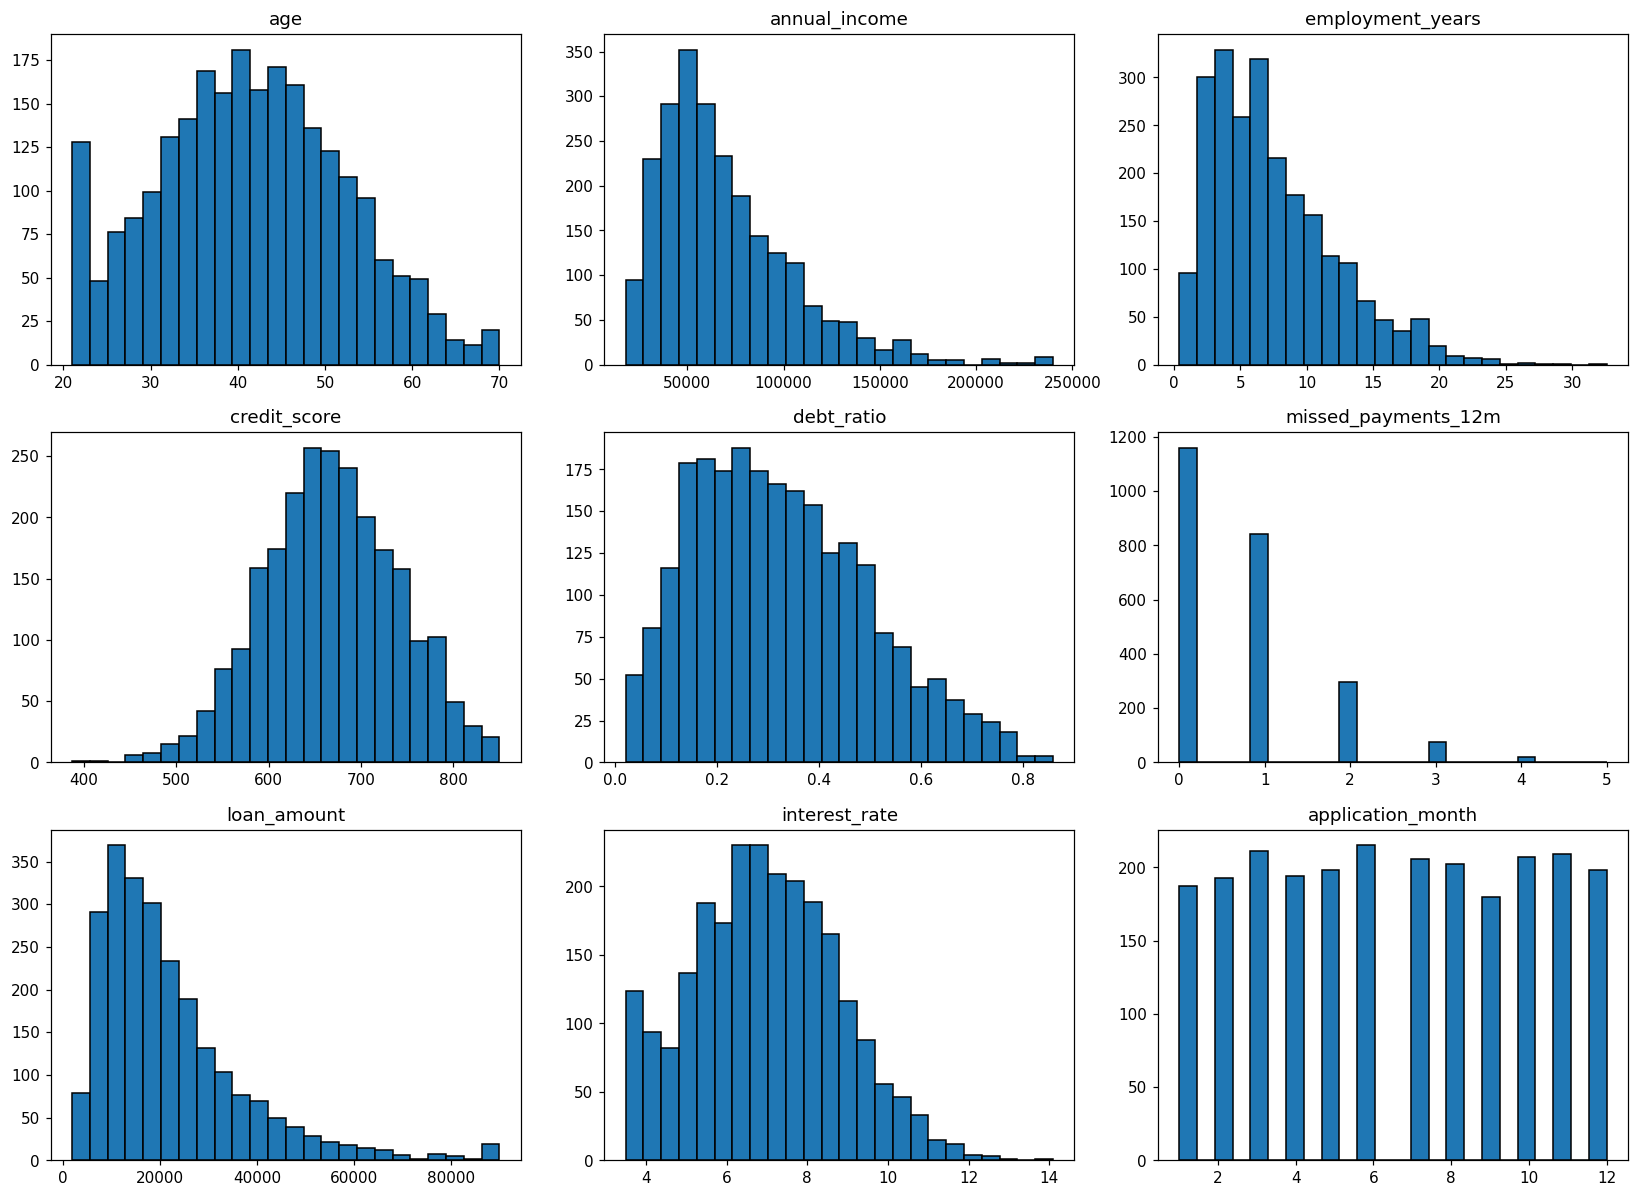

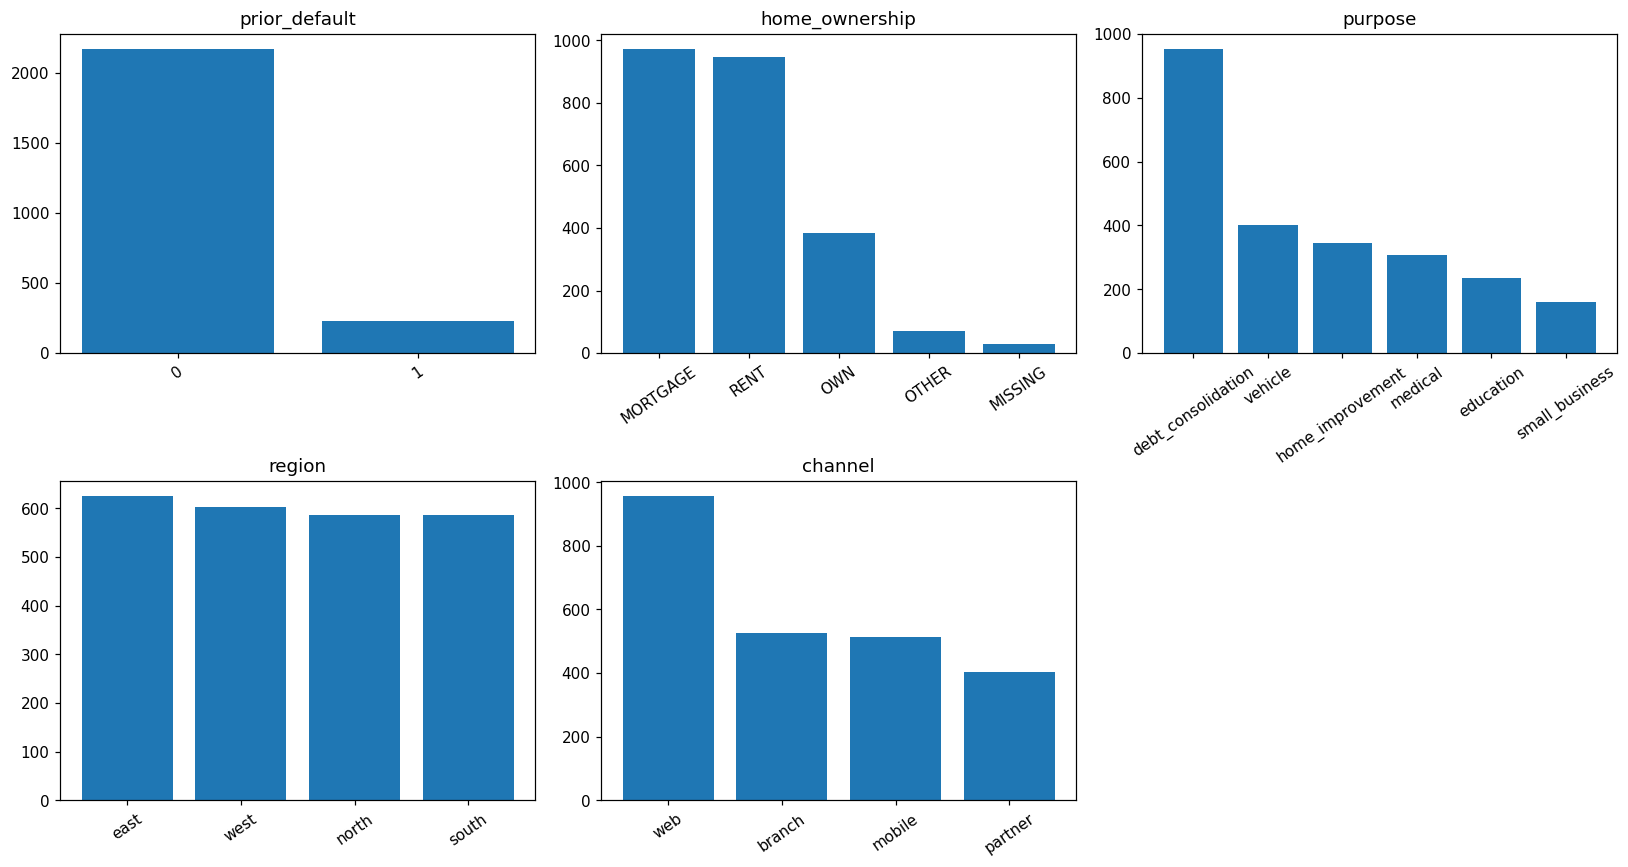

In [3]:
num=["age","annual_income","employment_years","credit_score","debt_ratio","missed_payments_12m","loan_amount","interest_rate","application_month"];cat=["prior_default","home_ownership","purpose","region","channel"];fig,axes=plt.subplots(3,3,figsize=(15,11));
for ax,col in zip(axes.flat,num):ax.hist(df[col].dropna(),bins=24,edgecolor="black");ax.set_title(col)
plt.tight_layout();plt.show();fig,axes=plt.subplots(2,3,figsize=(15,8));
for ax,col in zip(axes.flat,cat):s=df[col].astype("string").fillna("MISSING").value_counts();ax.bar(s.index.astype(str),s.values);ax.set_title(col);ax.tick_params(axis="x",rotation=35)
axes.flat[-1].axis("off");plt.tight_layout();plt.show();
for col in cat:display(df.groupby(col,dropna=False).default.agg(["count","mean"]).sort_values("mean",ascending=False))

## 3. Bivariate and multivariate analysis

Class-conditional distributions, target-rate tables, and rank correlations expose separation and interactions without implying causality.

default                1.000000
interest_rate          0.366057
debt_ratio             0.229976
loan_amount            0.051152
missed_payments_12m    0.049931
age                    0.019266
annual_income          0.007592
employment_years      -0.013856
application_month     -0.032931
credit_score          -0.354975
Name: default, dtype: float64

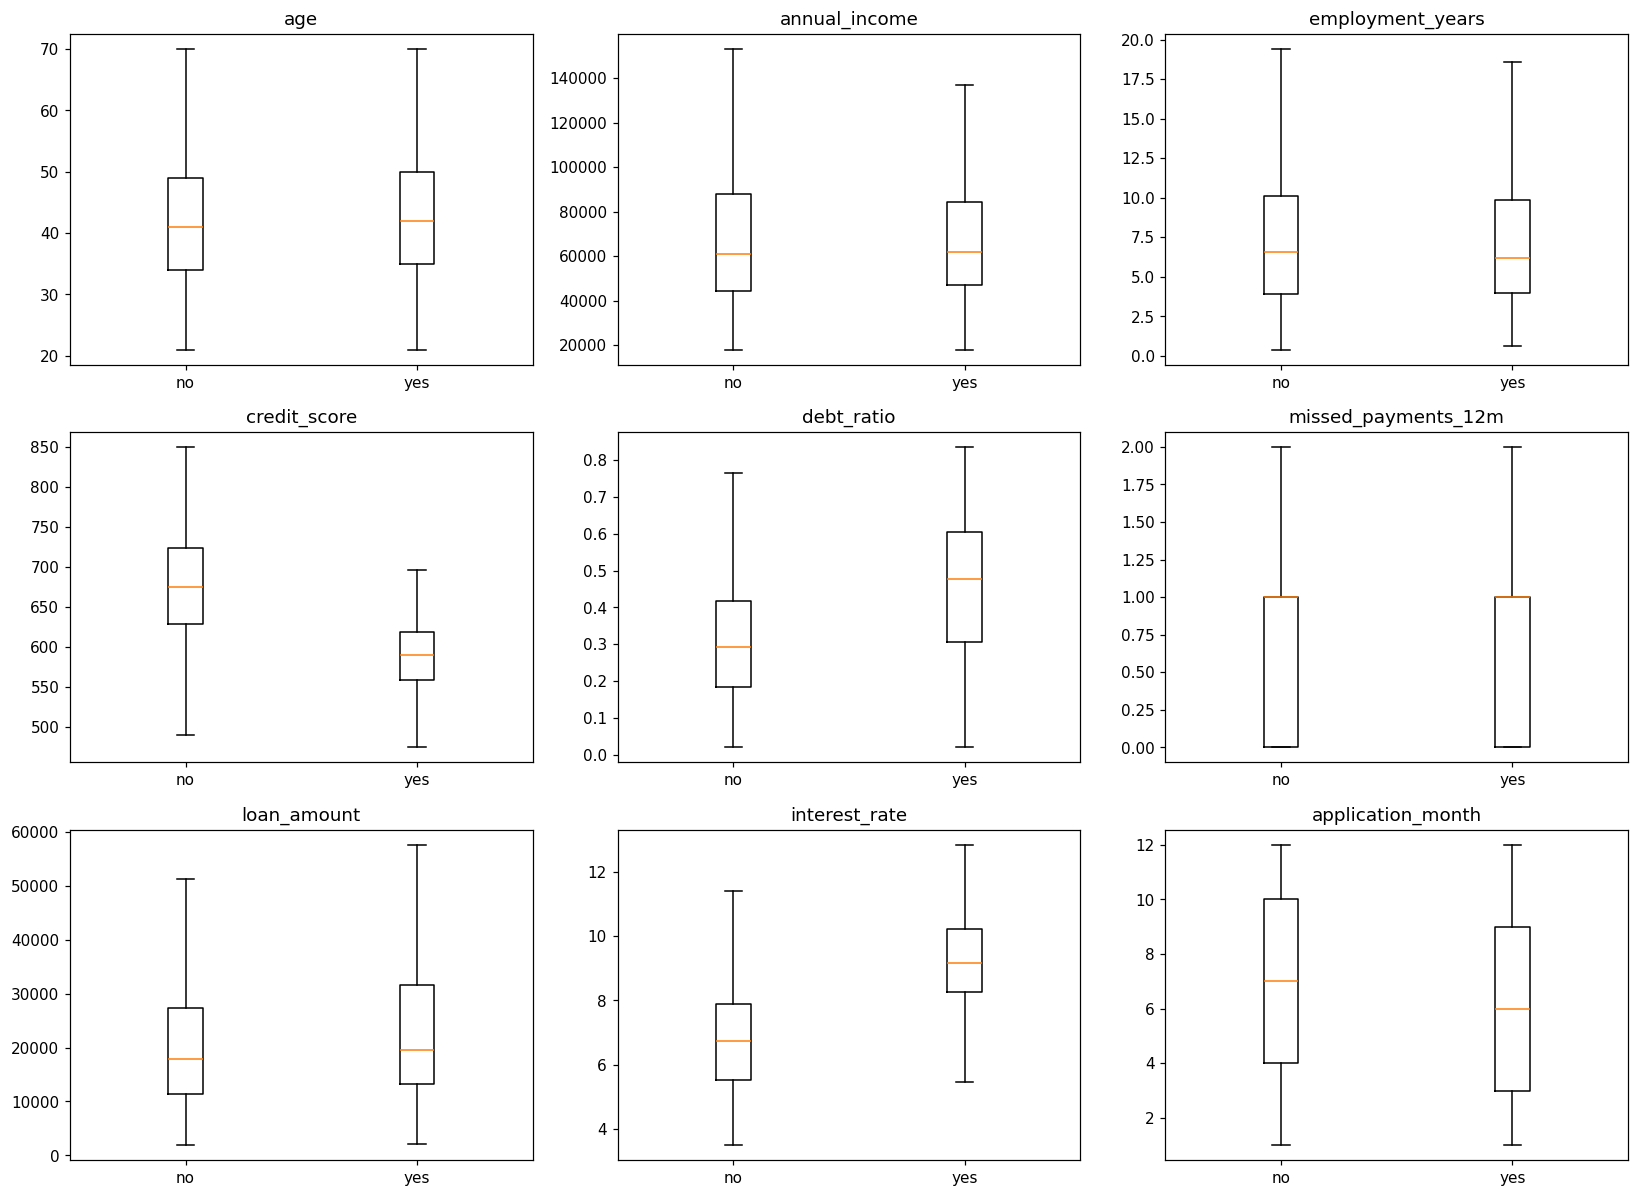

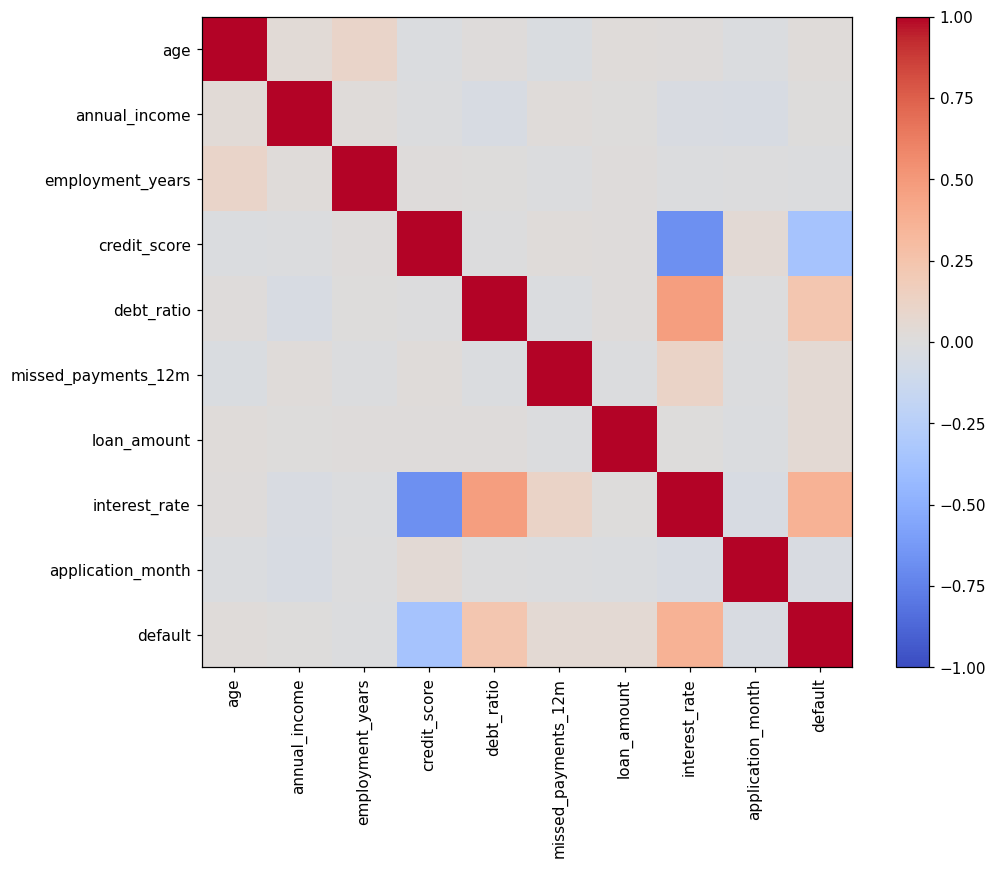

In [4]:
fig,axes=plt.subplots(3,3,figsize=(15,11));
for ax,col in zip(axes.flat,num):q=df[[col,"default"]].dropna();ax.boxplot([q.loc[q.default==k,col] for k in [0,1]],tick_labels=["no","yes"],showfliers=False);ax.set_title(col)
plt.tight_layout();plt.show();corr=df[num+["default"]].corr(method="spearman");fig,ax=plt.subplots(figsize=(10,8));im=ax.imshow(corr,vmin=-1,vmax=1,cmap="coolwarm");ax.set_xticks(range(len(corr)));ax.set_xticklabels(corr.columns,rotation=90);ax.set_yticks(range(len(corr)));ax.set_yticklabels(corr.index);fig.colorbar(im,ax=ax);plt.tight_layout();plt.show();display(corr["default"].sort_values(ascending=False))

## 4. Leakage-safe experimental design

Test is isolated before preprocessing, tuning, and threshold selection. Validation supports model and policy decisions. Cross-validation occurs within training.

In [5]:
X=df.drop(columns=["customer_id","default"]);y=df.default.astype(int);X_train,X_tmp,y_train,y_tmp=train_test_split(X,y,test_size=.4,stratify=y,random_state=SEED);X_valid,X_test,y_valid,y_test=train_test_split(X_tmp,y_tmp,test_size=.5,stratify=y_tmp,random_state=SEED);numeric=[c for c in X.columns if c not in cat];pre=ColumnTransformer([("num",SimpleImputer(strategy="median"),numeric),("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat)],verbose_feature_names_out=False);print(X_train.shape,X_valid.shape,X_test.shape)

(1440, 14) (480, 14) (480, 14)


In [6]:
def evaluate(name,m,Xe,ye,t=.5):
 p=m.predict_proba(Xe)[:,1];z=(p>=t).astype(int);return {"model":name,"roc_auc":roc_auc_score(ye,p),"average_precision":average_precision_score(ye,p),"balanced_accuracy":balanced_accuracy_score(ye,z),"f1":f1_score(ye,z),"mcc":matthews_corrcoef(ye,z),"log_loss":log_loss(ye,p),"brier":brier_score_loss(ye,p)},p,z
def cost(y,p,t):
 tn,fp,fn,tp=confusion_matrix(y,(p>=t).astype(int)).ravel();return fp+6*fn

In [7]:
rng=np.random.default_rng(SEED);toy=np.arange(12)
for i in range(4):
 s=rng.choice(toy,len(toy),replace=True);print({"tree":i+1,"bootstrap":s.tolist(),"oob":np.setdiff1d(toy,np.unique(s)).tolist()})

{'tree': 1, 'bootstrap': [2, 8, 9, 11, 5, 11, 10, 9, 2, 0, 4, 2], 'oob': [1, 3, 6, 7]}
{'tree': 2, 'bootstrap': [8, 9, 6, 0, 6, 5, 1, 1, 1, 8, 6, 11], 'oob': [2, 3, 4, 7, 10]}
{'tree': 3, 'bootstrap': [11, 0, 4, 9, 10, 7, 0, 0, 2, 4, 9, 7], 'oob': [1, 3, 5, 6, 8]}
{'tree': 4, 'bootstrap': [9, 8, 10, 5, 5, 1, 5, 7, 2, 1, 3, 2], 'oob': [0, 4, 6, 11]}


## 5. Baseline ladder

In [8]:
models={"majority":Pipeline([("prep",clone(pre)),("model",DummyClassifier(strategy="prior"))]),"logistic":Pipeline([("prep",clone(pre)),("model",LogisticRegression(max_iter=1500,class_weight="balanced",random_state=SEED))]),"single_tree":Pipeline([("prep",clone(pre)),("model",DecisionTreeClassifier(max_depth=6,min_samples_leaf=20,class_weight="balanced",random_state=SEED))]),"forest":Pipeline([("prep",clone(pre)),("model",RandomForestClassifier(n_estimators=60,min_samples_leaf=5,max_features="sqrt",class_weight="balanced_subsample",oob_score=True,n_jobs=1,random_state=SEED))])};rows=[]
for name,m in models.items():m.fit(X_train,y_train);rows.append(evaluate(name,m,X_valid,y_valid)[0])
display(pd.DataFrame(rows).set_index("model").sort_values("roc_auc",ascending=False));print("OOB",models["forest"].named_steps["model"].oob_score_)

OOB 0.8875


,roc_auc,average_precision,balanced_accuracy,f1,mcc,log_loss,brier
model,,,,,,,
forest,0.910204,0.627349,0.755787,0.523364,0.467416,0.253792,0.072901
single_tree,0.907263,0.554604,0.827546,0.454054,0.435169,0.492707,0.125129
logistic,0.887105,0.497770,0.831019,0.461538,0.442746,0.478590,0.152028
majority,0.500000,0.100000,0.500000,0.000000,0.000000,0.325086,0.090000


## 6. Tree-count convergence and capacity controls

,leaf,max_features,train_auc,valid_auc
0,2,sqrt,0.999978,0.922791
5,15,0.7,0.960991,0.916257
3,6,0.7,0.985674,0.914087
1,2,0.7,0.999768,0.912953
2,6,sqrt,0.988376,0.910349
4,15,sqrt,0.960792,0.901331


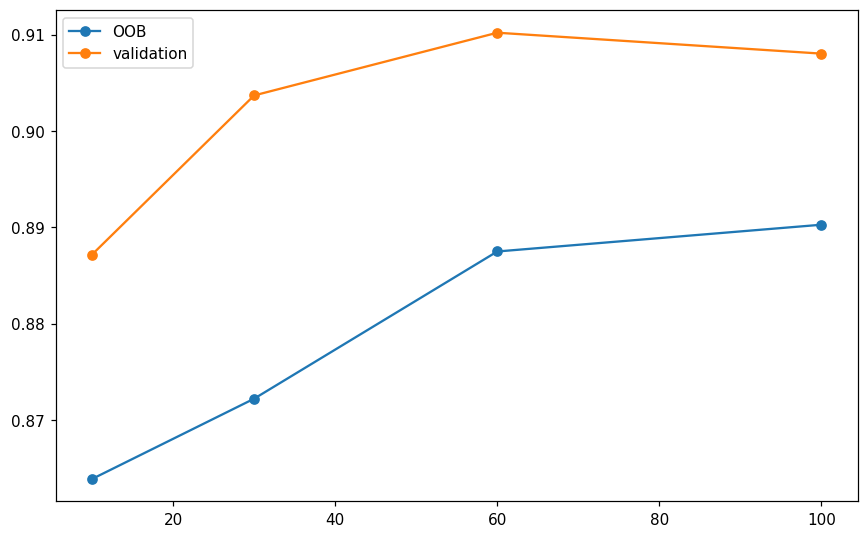

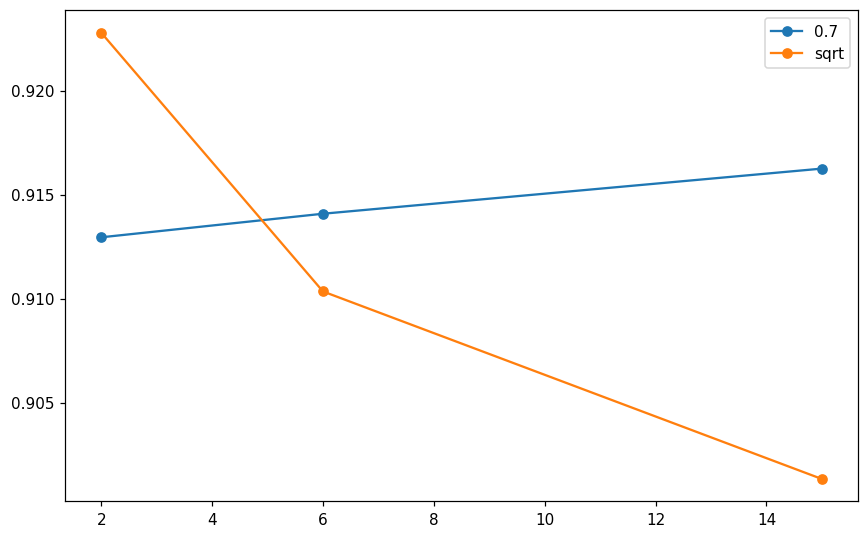

In [9]:
rows=[]
for count in [10,30,60,100]:
 m=Pipeline([("prep",clone(pre)),("model",RandomForestClassifier(n_estimators=count,min_samples_leaf=5,max_features="sqrt",class_weight="balanced_subsample",oob_score=True,n_jobs=1,random_state=SEED))]).fit(X_train,y_train);rows.append({"trees":count,"oob":m.named_steps["model"].oob_score_,"valid_auc":roc_auc_score(y_valid,m.predict_proba(X_valid)[:,1])})
conv=pd.DataFrame(rows);fig,ax=plt.subplots(figsize=(8,5));ax.plot(conv.trees,conv.oob,marker="o",label="OOB");ax.plot(conv.trees,conv.valid_auc,marker="o",label="validation");ax.legend();plt.tight_layout();plt.show();rows=[]
for leaf in [2,6,15]:
 for mf in ["sqrt",.7]:
  m=Pipeline([("prep",clone(pre)),("model",RandomForestClassifier(n_estimators=50,min_samples_leaf=leaf,max_features=mf,class_weight="balanced_subsample",n_jobs=1,random_state=SEED))]).fit(X_train,y_train);rows.append({"leaf":leaf,"max_features":str(mf),"train_auc":roc_auc_score(y_train,m.predict_proba(X_train)[:,1]),"valid_auc":roc_auc_score(y_valid,m.predict_proba(X_valid)[:,1])})
cap=pd.DataFrame(rows);display(cap.sort_values("valid_auc",ascending=False));fig,ax=plt.subplots(figsize=(8,5));
for key,g in cap.groupby("max_features"):ax.plot(g.leaf,g.valid_auc,marker="o",label=key)
ax.legend();plt.tight_layout();plt.show()

## 7. Cross-validated tuning, stability, and diversity

{'model__class_weight': 'balanced_subsample', 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 80} 0.8781453330975535 0.8590277777777777


,mean_train_score,mean_test_score,params
3,0.976898,0.878145,"{'model__class_weight': 'balanced_subsample', ..."
1,0.996344,0.876797,"{'model__class_weight': 'balanced_subsample', ..."
2,0.976157,0.875707,"{'model__class_weight': 'balanced_subsample', ..."
0,0.996044,0.865850,"{'model__class_weight': 'balanced_subsample', ..."


,mean,std
fit_time,0.191057,0.001669
score_time,0.027885,0.000253
test_roc_auc,0.878145,0.039257
test_average_precision,0.437511,0.066149
test_balanced_accuracy,0.763376,0.042780
test_f1,0.483110,0.051660


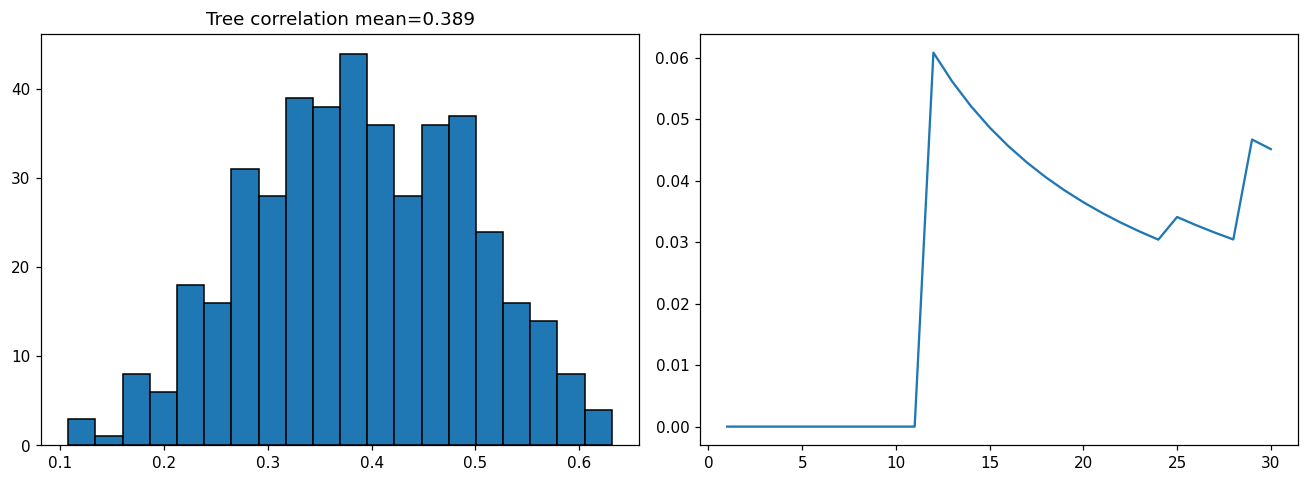

In [10]:
cv=StratifiedKFold(3,shuffle=True,random_state=SEED);pipe=Pipeline([("prep",clone(pre)),("model",RandomForestClassifier(oob_score=True,n_jobs=1,random_state=SEED))]);grid={"model__n_estimators":[50,80],"model__min_samples_leaf":[4,10],"model__max_features":["sqrt"],"model__class_weight":["balanced_subsample"]};search=GridSearchCV(pipe,grid,scoring="roc_auc",cv=cv,n_jobs=1,return_train_score=True).fit(X_train,y_train);final=search.best_estimator_;print(search.best_params_,search.best_score_,final.named_steps["model"].oob_score_);display(pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(8)[["mean_train_score","mean_test_score","params"]]);display(pd.DataFrame(cross_validate(final,X_train,y_train,cv=cv,scoring=["roc_auc","average_precision","balanced_accuracy","f1"],n_jobs=1)).agg(["mean","std"]).T);prep_f=final.named_steps["prep"];forest=final.named_steps["model"];Xv=prep_f.transform(X_valid);per_tree=np.column_stack([t.predict_proba(Xv)[:,1] for t in forest.estimators_[:30]]);corr=np.corrcoef(per_tree,rowvar=False);upper=corr[np.triu_indices_from(corr,k=1)];fig,axes=plt.subplots(1,2,figsize=(12,4.5));axes[0].hist(upper,bins=20,edgecolor="black");axes[0].set_title(f"Tree correlation mean={upper.mean():.3f}");axes[1].plot(np.arange(1,31),np.cumsum(per_tree[0])/np.arange(1,31));plt.tight_layout();plt.show()

## 8. Importance and partial dependence

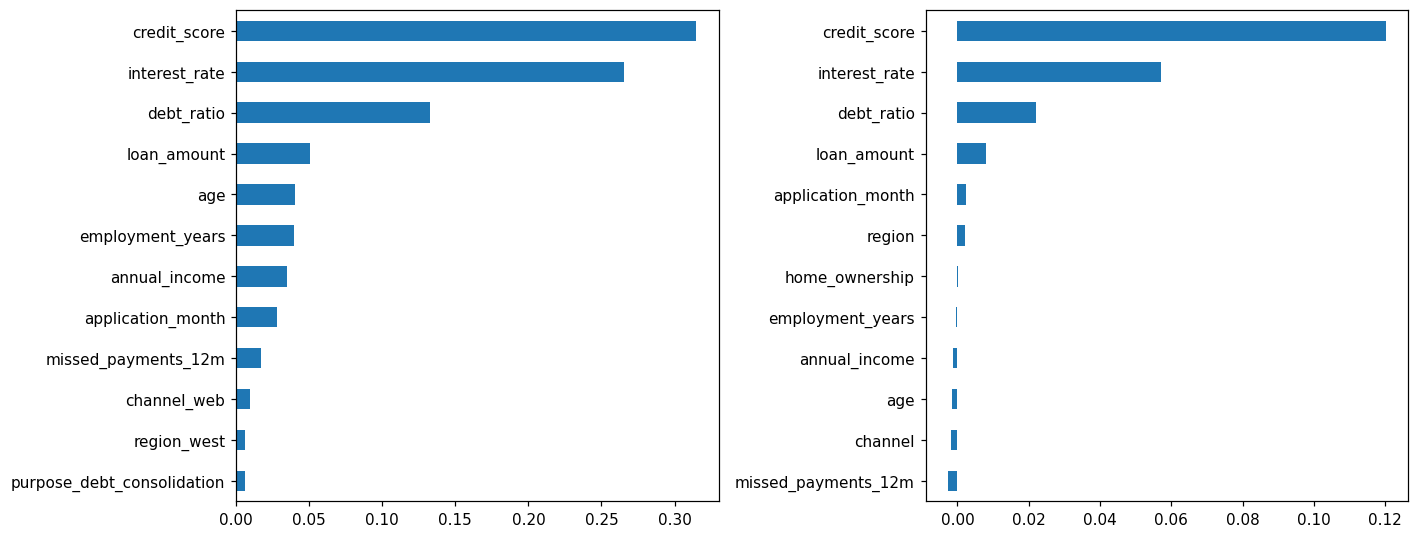

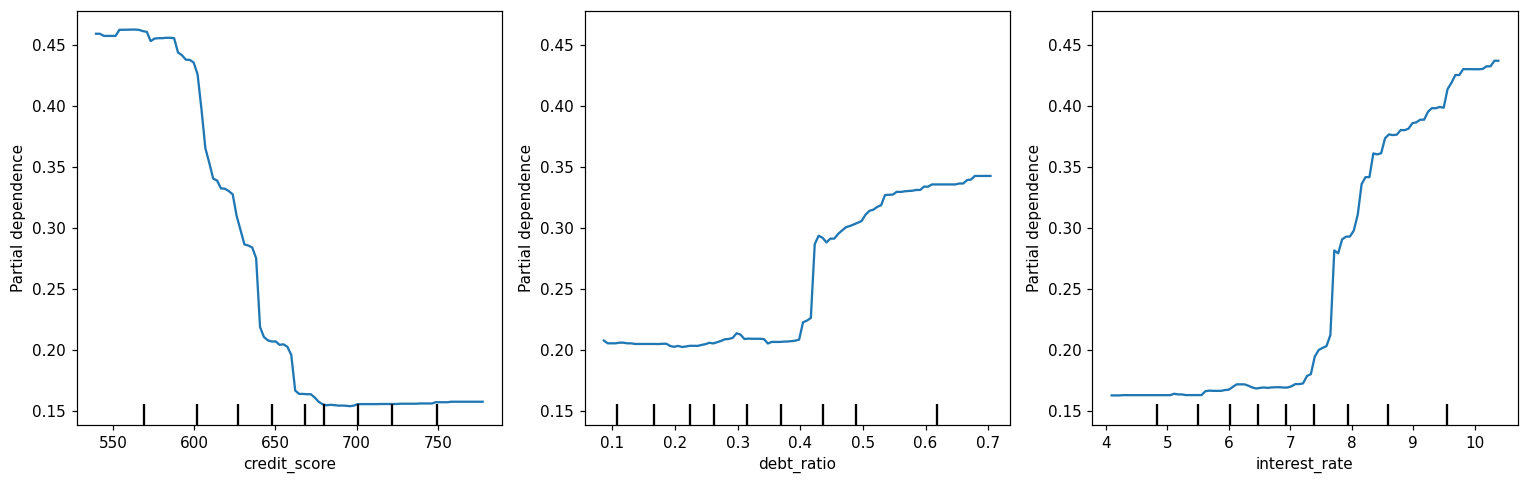

In [11]:
names=final.named_steps["prep"].get_feature_names_out();mdi=pd.Series(forest.feature_importances_,index=names).sort_values(ascending=False);perm=permutation_importance(final,X_valid,y_valid,scoring="roc_auc",n_repeats=3,random_state=SEED,n_jobs=1);per=pd.Series(perm.importances_mean,index=X_valid.columns).sort_values(ascending=False);fig,axes=plt.subplots(1,2,figsize=(13,5));mdi.head(12).sort_values().plot.barh(ax=axes[0]);per.head(12).sort_values().plot.barh(ax=axes[1]);plt.tight_layout();plt.show();fig,ax=plt.subplots(1,3,figsize=(14,4.5));PartialDependenceDisplay.from_estimator(final,X_valid,["credit_score","debt_ratio","interest_rate"],ax=ax);plt.tight_layout();plt.show()

## 9. Probability policy, untouched-test comparison, subgroup diagnostics, and deployment

              precision    recall  f1-score   support

           0     0.9719    0.8819    0.9248       432
           1     0.4205    0.7708    0.5441        48

    accuracy                         0.8708       480
   macro avg     0.6962    0.8264    0.7344       480
weighted avg     0.9168    0.8708    0.8867       480



,roc_auc,average_precision,balanced_accuracy,f1,mcc,log_loss,brier
model,,,,,,,
random_forest_final,0.912375,0.601622,0.826389,0.544118,0.506108,0.303295,0.090879
logistic,0.880691,0.506476,0.810185,0.444444,0.416809,0.457166,0.147483
single_tree,0.831718,0.500890,0.768519,0.387755,0.348873,0.977495,0.151834


,feature,level,n,roc_auc,f1
0,home_ownership,MORTGAGE,190,0.886119,0.474576
1,home_ownership,OTHER,17,1.000000,1.000000
2,home_ownership,OWN,73,0.942857,0.285714
3,home_ownership,RENT,196,0.912381,0.603774
4,purpose,debt_consolidation,178,0.878858,0.480000
5,purpose,education,48,0.930233,0.615385
6,purpose,home_improvement,76,0.917184,0.500000
7,purpose,medical,64,0.975000,0.461538
8,purpose,small_business,27,0.989130,0.888889
9,purpose,vehicle,87,0.884444,0.580645


algorithm                                    RandomForestClassifier
intended_use                                              education
prohibited_use                                real credit decisions
test_metrics      {'model': 'random_forest_final', 'roc_auc': 0....
limits            [synthetic data, importance is noncausal, cali...
dtype: object

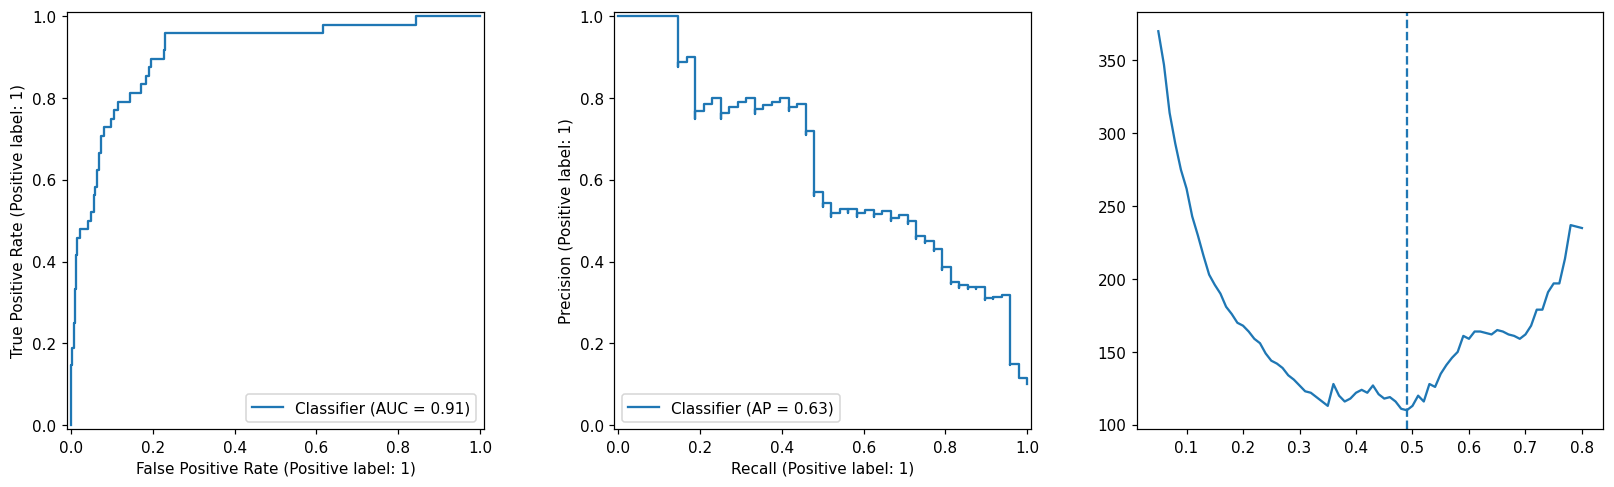

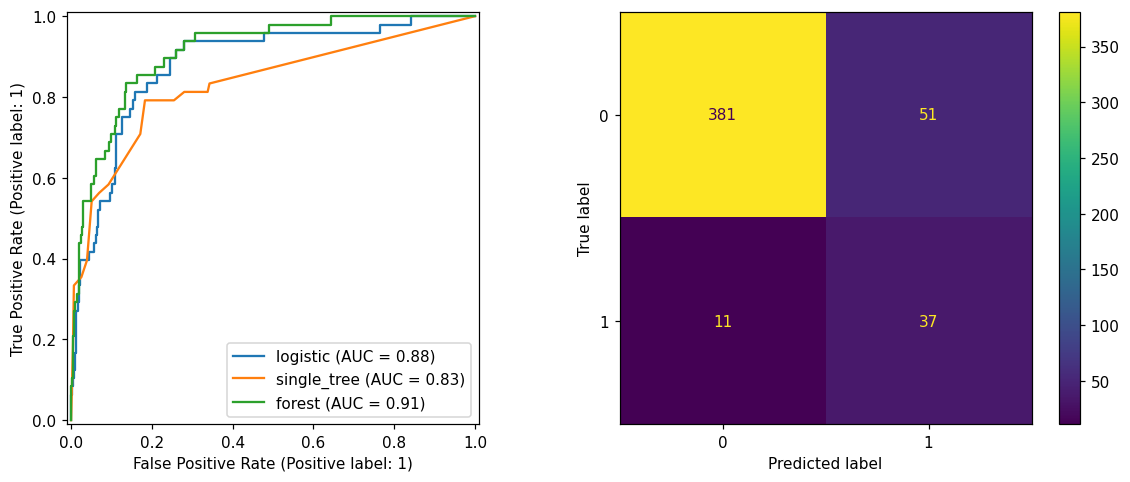

In [12]:
vm,vp,_=evaluate("forest",final,X_valid,y_valid);ts=np.linspace(.05,.8,76);costs=np.array([cost(y_valid,vp,t) for t in ts]);threshold=float(ts[costs.argmin()]);fig,axes=plt.subplots(1,3,figsize=(15,4.5));RocCurveDisplay.from_predictions(y_valid,vp,ax=axes[0]);PrecisionRecallDisplay.from_predictions(y_valid,vp,ax=axes[1]);axes[2].plot(ts,costs);axes[2].axvline(threshold,ls="--");plt.tight_layout();plt.show();rows=[];preds={}
for name in ["logistic","single_tree"]:
 m,p,z=evaluate(name,models[name],X_test,y_test,threshold);rows.append(m);preds[name]=(p,z)
tm,tp,pred=evaluate("random_forest_final",final,X_test,y_test,threshold);rows.append(tm);preds["forest"]=(tp,pred);display(pd.DataFrame(rows).set_index("model").sort_values("roc_auc",ascending=False));fig,axes=plt.subplots(1,2,figsize=(11,4.5));
for name,(p,z) in preds.items():RocCurveDisplay.from_predictions(y_test,p,ax=axes[0],name=name)
ConfusionMatrixDisplay.from_predictions(y_test,pred,ax=axes[1]);plt.tight_layout();plt.show();print(classification_report(y_test,pred,digits=4));audit=X_test[["home_ownership","purpose","channel"]].copy();audit["y"]=y_test.values;audit["p"]=tp;audit["pred"]=pred;rows=[]
for f in ["home_ownership","purpose","channel"]:
 for level,g in audit.groupby(f,dropna=False):
  if len(g)>=15 and g.y.nunique()>1:rows.append({"feature":f,"level":level,"n":len(g),"roc_auc":roc_auc_score(g.y,g.p),"f1":f1_score(g.y,g.pred,zero_division=0)})
display(pd.DataFrame(rows));artifact={"model":final,"threshold":threshold,"feature_columns":X.columns.tolist()};joblib.dump(artifact,ROOT/"artifacts"/"random_forest_classifier.joblib");card={"algorithm":"RandomForestClassifier","intended_use":"education","prohibited_use":"real credit decisions","test_metrics":tm,"limits":["synthetic data","importance is noncausal","calibration not guaranteed"]};(ROOT/"model_card.json").write_text(json.dumps(card,indent=2));display(pd.Series(card))

## Final mental model

A forest reduces tree variance through bootstrap aggregation and random feature subspaces. Tree count stabilizes the average; leaf size and feature sampling govern the bias-correlation trade-off. OOB estimates, validation, diversity, interpretation limits, probability evaluation, and explicit threshold policy complete the workflow.